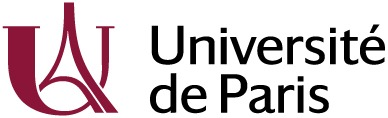
## M2 VMI - TP AD: Semantic segmentation using CNNs on remote sensing images

Pre-requisite: having a google account (sorry about that...)

## 1) Loading the data
The first thing we need to do is to get access to the data.

For this, you are going to copy the Vaihingen dataset in your own Google drive. Access the folder [here](https://drive.google.com/drive/folders/1Tr3q8kjPDzoamNFuHv7vTBsj5-acJC7Z?usp=sharing) and copy it to your drive.

Once this is done, you need to mount your drive in this script. This is done by executing the following two lines. You will need to authorize google collab to access to your drive (it will ask you to open a link and give you a confirmation code that you will have to copy on the text field bellow).

Exécutez la commande d'authentification dans votre notebook Colab pour lier votre compte.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

We should now have access to our data in google drive, check it by running this command. Depending on where you saved the folder, you might have to change the path.

In [ ]:
ls /content/drive/My\ Drive/Workshop_Semantic_Segmentation

To make things a bit cleaner, let's save this base directory:

In [ ]:
base_folder = '/content/drive/My Drive/Workshop_Semantic_Segmentation'

## 2) Understanding the task
Now that we have access to the data, let's do something with it!

What we want to do is called *semantic segmentation*. In short, we want to give a class to each pixel of the input image. To better understand the task, let's execute the following code:

In [ ]:
import skimage.io as io
import matplotlib.pyplot as plt
import os

tile = 'top_mosaic_09cm_area1.tif'
image_path = os.path.join(base_folder, 'DataVaihingen/top/', tile)
image = io.imread(image_path)
GT_path = os.path.join(base_folder, 'DataVaihingen/GT/', tile)
GT = io.imread(GT_path)
figure = plt.figure()
figure.add_subplot(1, 2, 1)
plt.imshow(image)
figure.add_subplot(1, 2, 2)
plt.imshow(GT)

We just printed one image and its ground truth (i.e. what we would like to be able to estimate).

If you go to the [website of the dataset](https://www.isprs.org/education/benchmarks/UrbanSemLab/2d-sem-label-vaihingen.aspx), you can get the legend:
1. Impervious surfaces (RGB: 255, 255, 255)
2. Building (RGB: 0, 0, 255)
3. Low vegetation (RGB: 0, 255, 255)
4. Tree (RGB: 0, 255, 0)
5. Car (RGB: 255, 255, 0)
6. Clutter/background (RGB: 255, 0, 0)

So in short, we want to approximate a function which takes an image as input (more specifically *near, red, green* images) and return an image of the same spatial size where each pixel can have one of the 6 values defined above.

## 3) Model
### 3.1) Network class

To do this task, we are going to use CNNs. So the first thing we want to do is to define the architecture. As a first model, we are going to build a model called 'hypercolumn'.

Here is an illustration of the model:


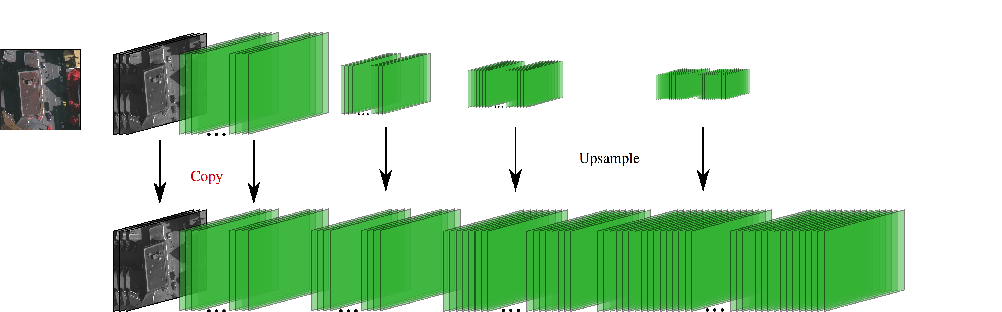

To implement it in pytorch, we will define a class. This class inherits nn.Module and needs to implement two methods:
1. \_\_init\_\_(self): the method which will be called upon initialization of the model
2. forward(self, input): the method which will feedforward the input into the network, and needs to return the output of the network.

You can find a minimal example (an empty network) below

In [ ]:
import torch
import torch.nn as nn

class NetworkSample(nn.Module):
    def __init__(self):
        super(NetworkSample, self).__init__()


    def forward(self, x):
        #Do something with x:
        #e.g. output = f(x)
        #return output
        return None


### 3.2) Building blocks of a CNN
As we have seen during the intro, a CNN is made of three main ingredients:
1. Convolutions: in pytorch, a 2D convolution is defined as follow:
> nn.Conv2d(number_input_channels, number_output_channels, kernel_size)
2. Pooling layers: as we have seen, there are several types of pooling layers. We will use maxpooling:
> nn.MaxPool2d(kernel_size)
3. Activation function: once again, there are several activation functions. For instance, Tanh:
> nn.Tanh()

One more less classical building block that we will need to build our hypercolumn model is the upsample function:
> nn.Upsample(size_to_which_we_should_interpolate, mode='bilinear')

The typical way of defining a network is to instantiate the building blocks in the \_\_init\_\_ function of the network, and to use them in the forward function to predict the output. So let's do that!

In [ ]:
class Hypercolumns(nn.Module):
    def __init__(self):
        super(Hypercolumns, self).__init__()

        #Define the convolution layers
        self.conv1 = nn.Conv2d(3, 64, 7)
        self.conv2 = nn.Conv2d(64, 64, 5)
        self.conv3 = nn.Conv2d(64, 128, 5)
        self.conv4 = nn.Conv2d(128, 256, 5)

        #Pooling layer and activation:
        self.pool = nn.MaxPool2d(3)
        self.activation = nn.Tanh()

        #The interpolation. Note that it will upsample any input size to 512*512
        self.interpol = nn.Upsample(size=(512,512), mode='bilinear', align_corners=True)

        #And the final MLP layers. Note that we use 1*1 convolution for that.
        self.MLP1 = nn.Conv2d((256+128+64+64+3), 128, 1)
        self.MLP2 = nn.Conv2d(128, 128, 1)
        self.MLP3 = nn.Conv2d(128, 6, 1)

    def forward(self, x):
        #TODO: Define the forward pass:
        #You will need to use torch.cat on the upsampled activation maps to build the hypercolumn

        return #TODO

We can now check that it works by feeding a simple input (an empty image) to our network. Note that in pytorch, 2D inputs are defined as $(N, C, H, W)$ where $N$ is the number of samples (in our case 1), $C$ is the number of channels (in our case 3) and $H$ and $W$ are the height and width of the sample respectively.

In [ ]:
network = Hypercolumns()

dummy_sample = torch.zeros(1,3,512,512)
output = network(dummy_sample)
print(output.shape)

Therefore, we obtained an output of the same spatial input size, but with 6 channels (one for each class), which is what we wanted!

### 3.3) Loading the data

The next step is to construct a dataset class. This step is not *absolutely* mandatory, but as we are generally dealing with important amount of data, recommended.

In our case (which is rather simple), we use this class to make the training/validation/test splits, crop our images to patches of regular size ($512\times 512$) and transform the image so that pytorch understands it (change the data from a numpy array to a tensor and shift the values to the [0;1] range).

In [ ]:
import os

from skimage import io
import numpy as np

import torch
from torch.utils.data import Dataset
import torchvision.transforms as T

#Define the data splits. Here, we took the "official" ones from ISPRS.
split_imgs = {}
split_imgs["train"] = [1,3,5,7,11,13,15,17,21,23,26]
split_imgs["val"] = [28,30,32,34,37]
split_imgs["test"] = [2,4,6,8,10,12,14,16,20,22,24,27,29,31,33,35,38]

class VaihingenDataset(Dataset):
  def __init__(self, img_folder, GT_folder, split, patch_size=512):
    self.imgs = []
    self.GTs = []

    #This will convert the numpy array to a tensor
    conversion = T.ToTensor()
    #Amount of overlap when defining the patches. If your dataset is big enough,
    #you might not need to have overlaps
    overlap = patch_size // 2

    for img_index in split_imgs[split]:
      print("Working on image " + str(img_index))
      #Load the tile and the corresponding ground truth.
      img = io.imread(os.path.join(img_folder, "top_mosaic_09cm_area" + str(img_index) + '.tif')) / 255
      GT = io.imread(os.path.join(GT_folder, "top_mosaic_09cm_area" + str(img_index) + '.tif'))

      #Crop into patches, following a regularly sampled grid.
      #i and j are defined as the center of the patch to crop.
      for i in np.arange(patch_size//2, img.shape[0] - patch_size // 2, overlap):
        for j in np.arange(patch_size//2, img.shape[1] - patch_size // 2, overlap):
          #Crop the image and the ground truth into patch around (i,j) and save
          #them in self.imgs and self.GTs arrays.
          #For the image, note that we are taking the three channels (using ":")
          #for the 3rd dimension, and we do the conversion to tensor.
          self.imgs.append(conversion(img[i - patch_size//2:i + patch_size // 2, j - patch_size // 2:j + patch_size // 2,:]))
          self.GTs.append(GT[i - patch_size//2:i + patch_size // 2, j - patch_size // 2:j + patch_size // 2])

  def __len__(self):
    return len(self.imgs)

  def __getitem__(self, idx):
    #__getitem__ asks for the sample number idx. Since we pre-loaded the images
    #and the ground truths, we just have to return the corresponding sample.
    img = self.imgs[idx].float()
    GT = self.GTs[idx]

    #We also need to return the ground truth as a tensor
    return img, torch.from_numpy(GT)

One we have a dataset class, we can use it in a so-called dataloader. This is a class which will help us to load the data in batches (to speed-up computation).

A batch is a list of inputs that will be fed to the network at once (making use of the ability of our machines to do parallel operations). To select these samples, there are several sampling strategies which can be used (mostly sequential and random). Both of these strategies are already implemented in pytorch:

In [ ]:
batch_size = 3 #The batch size should generally be as big as your machine can take it.

#Note that we are using ground truth in the folder '1CGT'. They are not RGB anymore, but one channel.
training_dataset = VaihingenDataset(os.path.join(base_folder, 'DataVaihingen/top/'), os.path.join(base_folder, 'DataVaihingen/1CGT/'), 'train')
validate_dataset = VaihingenDataset(os.path.join(base_folder, 'DataVaihingen/top/'), os.path.join(base_folder, 'DataVaihingen/1CGT/'), 'val')

#Note that we shuffle the data for the training set, but not for the validation set:
train_loader = torch.utils.data.DataLoader(dataset=training_dataset, batch_size=batch_size, shuffle=True)
validate_loader = torch.utils.data.DataLoader(dataset=validate_dataset, batch_size=batch_size, shuffle=False)

### 3.4) Training the model

Now that we have a model and our training data, we are going to be able to actually train the model.

The most common way to train such a model is to proceed by *epochs*: during one epoch, we go through the training set once (feedforwarding the batches and backpropagate the gradients). Then we will compute the loss on the validation set to check that we are not overfitting or underfitting.

So the first thing we want to do is to define the loss function. Once again, pytorch implements several of them. The one that we will use is a classification loss (after all, we are trying to assign a class to each of the pixels) and is called the cross-entropy. It is defined as follow:

$l(\mathbf{y_i}, \hat{y}_i) = -  \log \left(\frac{exp(y_{i,\hat{y}_i})}{\sum_c exp(y_{i,c})}\right)$, where $y_{i,c}$ is the score of class $c$ at pixel $i$. To use it in pytorch, we just instantiate the following:

In [ ]:
loss_function = torch.nn.CrossEntropyLoss()

Then, we want to use an optimizer. In pytorch, you have to instantiate an object which will keep track of the current state and of the parameters to optimize. The most simple optimization algorithm that you can use is the stochastic gradient descent (SGD):

In [ ]:
optimizer = torch.optim.SGD(network.parameters(), lr=0.001)

We now have all the ingredients required to do the training!

So let's build our training loop and run it!

**Careful:**
* you should enable GPU in your collab at this point. To do so go to runtime -> Change runtime type -> Hardware accelerator and select "GPU";
* the default epoch number (3) should run in around 5min (on GPU).

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
from torch.autograd import Variable
from tqdm.autonotebook import tqdm #progression bar

number_epochs = 2
network.to(device)

training_losses = []
validation_losses = []

for epoch in range(number_epochs):
  print("Starting epoch number " + str(epoch))

  #Training phase:
  training_loss = 0
  network.train() #indicate to the network that we enter training mode

  for i, (inputs, GTs) in enumerate(tqdm(train_loader)):
    #Convert the inputs and GTs to torch Variable (will hold the computation
    #graph) and send them to the computation device (i.e. GPU).
    inputs = Variable(inputs).to(device)
    GTs = Variable(GTs).type(torch.LongTensor).to(device)

    #We set the gradients of the model to 0.
    optimizer.zero_grad()
    pred = network(inputs)
    loss = loss_function(pred, GTs)
    #We accumulate the gradients...
    loss.backward()
    #...and we update the parameters according to the gradients.
    optimizer.step()
    training_loss += loss.cpu().item() / len(train_loader)

  print("At epoch #" + str(epoch) + ", loss = " + str(training_loss))
  training_losses.append(training_loss)

  #Validation phase:
  validation_loss = 0
  #You need to set the network to eval mode when using batch normalization (to
  #be consistent across evaluation samples, we use mean and stddev computed
  #during training when doing inference, as opposed to ones computed on the
  #batch) or dropout (you want to use all the parameters during inference).
  #In this exercise, we do not use these elements, so just for good practice!
  network.eval()

  #This line reduces the memory by not tracking the gradients. Also to be used
  #during inference.
  with torch.no_grad():
    for i, (inputs, GTs) in enumerate(tqdm(validate_loader)):
      inputs = Variable(inputs).to(device)
      GTs = Variable(GTs).type(torch.LongTensor).to(device)

      pred = network(inputs)
      loss = loss_function(pred, GTs)
      validation_loss += loss.cpu().item() / len(validate_loader)

  print("At epoch #" + str(epoch) + ", validation loss = " + str(validation_loss))
  validation_losses.append(validation_loss)

  if epoch > 0:
    plt.figure()
    plt.plot(np.arange(len(training_losses)), training_losses)
    plt.plot(np.arange(len(validation_losses)), validation_losses)
    plt.show()

#Optional, if you want to save your model:
#torch.save(network.state_dict(), os.path.join(base_folder, 'WeightsVaihingen/', 'Hypercolumns_' + str(number_epochs) + "epochs.pth")
torch.save(network.state_dict(), os.path.join(base_folder, 'WeightsVaihingen/', 'Hypercolumns_augm_weigths_' + str(number_epochs) + 'epochs.pth'))


Hopefully, your losses (both train and validation) decreased.
However, we only ran three epochs, which is not a lot, but we do not want to sit in front of our screen waiting forever during this workshop.

I ran exactly the same script for 200 epochs. Let's load the weights:

In [ ]:
weight_path = os.path.join(base_folder, 'WeightsVaihingen/', 'Hypercolumns_200epochs.pth')
network.load_state_dict(torch.load(weight_path))

You should get:
> \<All keys matched successfully\>

You can now check the validation loss with these weights:

In [ ]:
validation_loss = 0
network.eval()
with torch.no_grad():
  for i, (inputs, GTs) in enumerate(tqdm(validate_loader)):
    inputs = Variable(inputs).to(device)
    GTs = Variable(GTs).type(torch.LongTensor).to(device)

    pred = network(inputs)
    loss = loss_function(pred, GTs)
    validation_loss += loss.cpu().item() / len(validate_loader)

print("with weights" + weight_path + ", validation loss = " + str(validation_loss))

## 4) Evaluation
### 4.1) Metrics definition

Now that we have a nice model, let's check its performances. Indeed, while we are trying to optimize the cross entropy, this takes into account the individual class scores obtained by the model. In the end, you only care about the class selected by the model, whether it selected it by a short margin (i.e. its score was just above another class) or a large one.

Some classical metrics used to evaluate a semantic segmentation model are the per-class F1, the average F1 and the overall accuracy:

* Per-class F1 (for class $c$): $\textrm{F1}_c = 2\times \frac{\textrm{Precision}_c\times\textrm{Recall}_c}{\textrm{Precision}_c + \textrm{Recall}_c}$, with $\textrm{Precision}_c = \frac{\textrm{TP}_c}{\textrm{TP}_c + \textrm{FP}_c}$ and $\textrm{Recall}_c = \frac{\textrm{TP}_c}{\textrm{TP}_c + \textrm{FN}_c}$
* Average F1: $\textrm{AF1} = \frac{1}{C}\sum_c \textrm{F1}_c$
* Overall accuracy: $\textrm{OA} = \frac{\sum_c \textrm{TP}_c}{\textrm{T}}$

Where:
* $\textrm{TP}_c$ is the number of true positive for class $c$ (e.g. the number of pixels correctly predicted as $c$),  
* $\textrm{FP}_c$ is the number of false positive for class $c$ (e.g. the number of pixels incorrectly predicted as $c$),
* $\textrm{TN}_c$ is the number of true negative for class $c$ (e.g. the number of pixels correctly predicted as not $c$),
* $\textrm{FN}_c$ is the number of false negative for class $c$ (e.g. the number of pixels incorrectly predicted as not $c$).
* $\textrm{T}$ is the total number of pixels.

We can implement a function which takes two images and compute these metrics:

In [ ]:
from sklearn.metrics import confusion_matrix

valGT = [[255,255,255], [0,0,255], [0,255,255], [0,255,0], [255,255,0], [255,0,0]]
valGT_names = ["Impervious surfaces", "Building", "Low vegetation", "Trees", "Car", "Clutter/Background"]

def compute_confusion_matrix(prediction, ground_truth):
  confusion = confusion_matrix(ground_truth.flatten(), prediction.flatten(), labels = list(range(len(valGT))))
  return confusion

def compute_metrics(confusion):
  avg_f1 = 0
  avg_acc = 0
  overall_acc = 0
  metrics = {}
  for class_idx in range(6):
    #Compute TP, FP, FN, TN
    TP = #???
    #...

    #compute per class precision, recall and F1 score
    #f1_score = ?
    #precision = ?
    #recall = ?

    #Save the metrics in the dictionnary (metrics)
    metric_name = "f1_" + valGT_names[class_idx]
    metrics[metric_name] = f1_score
    metric_name = "precision_" + valGT_names[class_idx]
    metrics[metric_name] = precision
    metric_name = "recall_" + valGT_names[class_idx]
    metrics[metric_name] = recall

    avg_f1 += f1_score

  #Normalize
  metrics["average_f1"] = avg_f1 / 6
  #Compute overall accuracy
  metrics["overall_acc"] = #?

  return metrics

### 4.2) Producing the prediction maps

Now we have a function which takes a prediction map and the ground truth, but we can only produce prediction maps of patches. Indeed, we defined our model so it takes a $(512\times 512)$ image and returns an output of the same size.

Therefore, we need to crop our input image in patches of this size and paste the outputs together to produce a full-size prediction map. The following function is doing that:

In [ ]:
from torch.autograd import Variable

conversion = T.ToTensor()
patch_size = 512
batch_size = 3
network.eval()

def process_image(image):
  #Do not forget to put the image in the [0, 1] range, as we did for the training
  img = image / 255
  #Create the ouput map
  output = np.zeros((6, img.shape[0], img.shape[1]))

  #To speed up computation, we will compute by batches. However, to easily keep
  #track of the spatial location of the patches, we will create the batches by
  #hand
  batch = torch.zeros((batch_size, 3, patch_size, patch_size))
  batch_indices = []
  batch_number = 0

  #Create the patches
  for i in np.arange(0, img.shape[0], patch_size):
    iend = i + patch_size
    if iend > img.shape[0]:
      iend = img.shape[0]
    istart = iend - 512
    for j in np.arange(0, img.shape[1], patch_size):
      jend = j + patch_size
      if jend > img.shape[1]:
        jend = img.shape[1]
      jstart = jend - 512

      #You can uncomment the following line to see which patches are being created
      #print('Working on patch from (' + str(istart) + ', ' + str(jstart) + ') to (' + str(iend) + ', ' + str(jend) + ')')

      #Once again, let's not forget to convert the batches to tensor.
      torch_image = conversion(img[istart:iend, jstart:jend, :]).float()

      #fill the batches
      batch[batch_number,...] = torch_image
      batch_indices.append([istart, iend, jstart, jend])
      batch_number += 1

      #If the batch is filled, or it is the last patch, we compute the segmentation.
      if batch_number == batch_size or (iend == img.shape[0] and jend == img.shape[1]):
        #print('Sending to network...')
        input_batch = Variable(batch).to(device)
        preds = network(input_batch)
        #print('predictions done.')

        #And we fill the ouput.
        for output_num in range(batch_number):
          indices = batch_indices[output_num]
          pred = preds[output_num, ...]
          output[:, indices[0]:indices[1], indices[2]:indices[3]] = pred.data.cpu().numpy()

        batch_number = 0
        batch_indices = []

  return np.argmax(output, axis=0)

Notice the last line. We selected the class with the highest score as our prediction.

Therefore, we now have an image where each pixel is the indice of the predicted class. We will now define a function to vizualize the results in the same color code as the one used for the dataset:

In [ ]:
def convert_prediction(image):
  output = np.zeros((image.shape[0], image.shape[1], 3))

  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
      class_idx = image[i, j]
      output[i,j,:] = valGT[class_idx]

  return output.astype(int)

We can now try it on the first image of the dataset (note that this image is part of the training set...):

In [ ]:
image = io.imread(os.path.join(base_folder, 'DataVaihingen/top/', 'top_mosaic_09cm_area1.tif'))
output = process_image(image)
output = convert_prediction(output)
plt.imshow(output)


### 4.3) Producting the results on the test set

Now let's define a last function to produce the whole results on an image:

In [ ]:
def pretty_print_metrics(metrics):
  header = ""
  cell_len = 26
  print("-" * ((cell_len + 1) * 8 + 1))
  for key in valGT_names + ['Average F1', 'Overall accuracy']:
    header += "|"
    if key in valGT_names:
      cell = " F1 (" + key + ")"
    else:
      cell = " " + key
    header += cell

    pad = cell_len - len(cell)
    header += " " * pad
  header += "|"
  print(header)
  print("-" * ((cell_len + 1) * 8 + 1))

  metrics_vals = ""
  for key in valGT_names + ['average_f1', 'overall_acc']:
    metrics_vals += "|"
    if key in valGT_names:
      metric_key = "f1_" + key
    else:
      metric_key = key
    value = metrics[metric_key]
    metrics_vals += " %.4f" % round(value,4)

    pad = cell_len - 7
    if np.isnan(value):
      pad += 3
    metrics_vals += " " * pad
  metrics_vals += "|"
  print(metrics_vals)
  print("-" * ((cell_len + 1) * 8 + 1))

def produce_results(image_name):
  print("="*80)
  print(f"Results for {image_name}:")
  image = io.imread(os.path.join(base_folder, 'DataVaihingen/top/', image_name))
  output = process_image(image)
  GT = io.imread(os.path.join(base_folder, 'DataVaihingen/1CGT/', image_name)).astype(int)

  confusion = compute_confusion_matrix(output, GT)
  metrics = compute_metrics(confusion)

  #Print the images
  figure = plt.figure(figsize=(18, 16), dpi= 80, facecolor='w', edgecolor='k')
  ax1 = figure.add_subplot(1, 3, 1)
  ax1.title.set_text('Input')
  plt.imshow(image)
  ax2 = figure.add_subplot(1, 3, 2)
  ax2.title.set_text('Prediction')
  plt.imshow(convert_prediction(output))
  ax3 = figure.add_subplot(1, 3, 3)
  ax3.title.set_text('Ground truth')
  plt.imshow(convert_prediction(GT))
  plt.show()

  #Pretty printing of the metrics
  pretty_print_metrics(metrics)

  return confusion

We can now run this on the whole test set:

In [ ]:
for i, image_idx in enumerate(split_imgs["test"]):
  confusion = produce_results('top_mosaic_09cm_area' + str(image_idx) +'.tif')
  if i == 0:
    average_confusion_matrix = confusion
  else:
    average_confusion_matrix += confusion

average_metrics = compute_metrics(average_confusion_matrix)
print("On all images:")
pretty_print_metrics(average_metrics)

These should give you around 0.46 of average F1 score and an overall accuracy around 68.76%. Not too bad for a first model!

However, you can see that the per-class F1-score is not well distributed. For instance, we do not recognize any car. This is caused by imbalanced data (cars represent a small fraction of the pixels, and therefore learning to recognize cars does not lead to an important loss decrease).

What we have seen until now are the basics to train a network performing semantic segmentation. However, we can do a bit more. While not covered in this tutorial, here are some classical "tricks" to improve the performances:
1. Data augmentation.
2. Fighting the imbalance problem.
3. Using a better optimizer
4. Improving the inference.

Of course, there are also different networks that could give better performances (e.g. UNet)